### Prepare the data and visualizations so to be able for replicate it in Power BI or use a Dash/Streamlit app as a web-based dashboard. 
 
### ✅ Step-by-Step: Uber Data Analytics Dashboard in Python 
### 🛠️ Tools Used: 

### Pandas – for data processing
### Matplotlib, seaborn, plotly.express – for visualizations
### Streamlit – for dashboard deployment (optional)
     

In [1]:
!pip install streamlit plotly pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 73.3 MB/s eta 0:00:00


In [2]:
# CELL 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv("/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")

# Create DateTime and extract time features
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day_name()
df['Month'] = df['DateTime'].dt.month_name()

# Create flags
df['Is Completed'] = (df['Booking Status'] == 'Completed').astype(int)
df['Is Customer Cancelled'] = (df['Booking Status'] == 'Cancelled by Customer').astype(int)
df['Is Driver Cancelled'] = (df['Booking Status'] == 'Cancelled by Driver').astype(int)
df['Revenue'] = df['Booking Value'] * df['Is Completed']

print("✅ Data loaded and processed!")
df.head()

✅ Data loaded and processed!


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Customer Rating,Payment Method,DateTime,Hour,Day,Month,Is Completed,Is Customer Cancelled,Is Driver Cancelled,Revenue
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,2024-03-23 12:29:38,12,Saturday,March,0,0,0,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,UPI,2024-11-29 18:01:39,18,Friday,November,0,0,0,0.0
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,August,1,0,0,627.0
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,5.0,UPI,2024-10-21 17:17:25,17,Monday,October,1,0,0,416.0
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,4.3,UPI,2024-09-16 22:08:00,22,Monday,September,1,0,0,737.0


In [3]:
# CELL 2: Key Metrics
total_bookings = len(df)
completed_rides = df['Is Completed'].sum()
success_rate = completed_rides / total_bookings * 100
total_revenue = df['Revenue'].sum()

print(f"📊 Total Bookings: {total_bookings:,}")
print(f"✅ Completed Rides: {completed_rides:,}")
print(f"❌ Cancellation Rate: {100 - success_rate:.1f}%")
print(f"💰 Total Revenue: ₹{total_revenue:,.2f}")

📊 Total Bookings: 150,000
✅ Completed Rides: 93,000
❌ Cancellation Rate: 38.0%
💰 Total Revenue: ₹47,260,574.00


In [4]:
# CELL 3: Booking Status Pie Chart
status_counts = df['Booking Status'].value_counts()
fig1 = px.pie(values=status_counts.values, names=status_counts.index,
              title="Booking Status Distribution",
              color_discrete_sequence=px.colors.sequential.RdBu)
fig1.show()

In [5]:
# CELL 4: Daily Bookings Over Time
daily_bookings = df.groupby('Date').size().reset_index(name='Count')
fig2 = px.line(daily_bookings, x='Date', y='Count',
               title="📅 Daily Ride Bookings in 2024",
               labels={'Count': 'Number of Bookings'})
fig2.show()

In [6]:
# CELL 5: Success Rate by Vehicle Type
vehicle_success = df.groupby('Vehicle Type')['Is Completed'].mean().sort_values() * 100
fig3 = px.bar(vehicle_success, x=vehicle_success.values, y=vehicle_success.index, orientation='h',
              title="📈 Ride Success Rate by Vehicle Type (%)",
              text=[f'{val:.1f}%' for val in vehicle_success.values],
              color_continuous_scale='Blues', color=vehicle_success.values)
fig3.update_layout(xaxis_title="Success Rate (%)", yaxis_title="Vehicle Type")
fig3.show()

In [7]:
# CELL 6: Revenue by Payment Method
revenue_payment = df[df['Is Completed'] == 1].groupby('Payment Method')['Booking Value'].sum().reset_index()
fig4 = px.pie(revenue_payment, values='Booking Value', names='Payment Method',
              title="💵 Revenue Distribution by Payment Method",
              hole=0.4, color_discrete_sequence=px.colors.qualitative.Set2)
fig4.update_traces(textinfo='percent+label')
fig4.show()

In [8]:
# CELL 7: Average Ratings by Vehicle Type
ratings = df.groupby('Vehicle Type')[['Customer Rating', 'Driver Ratings']].mean().reset_index()
fig5 = px.bar(ratings, x='Vehicle Type', y=['Customer Rating', 'Driver Ratings'],
              title="⭐ Average Ratings by Vehicle Type",
              labels={'value': 'Rating', 'variable': 'Rating Type'},
              barmode='group')
fig5.show()

In [9]:
# CELL 8: Cancellation Reasons (Customer)
cust_cancel_reasons = df[df['Is Customer Cancelled'] == 1]['Reason for cancelling by Customer'].value_counts()
fig6 = px.bar(cust_cancel_reasons, x=cust_cancel_reasons.index, y=cust_cancel_reasons.values,
              title="🛑 Customer Cancellation Reasons",
              labels={'x': 'Reason', 'y': 'Count'}, color_discrete_sequence=['#EF553B'])
fig6.update_layout(xaxis_tickangle=-45)
fig6.show()

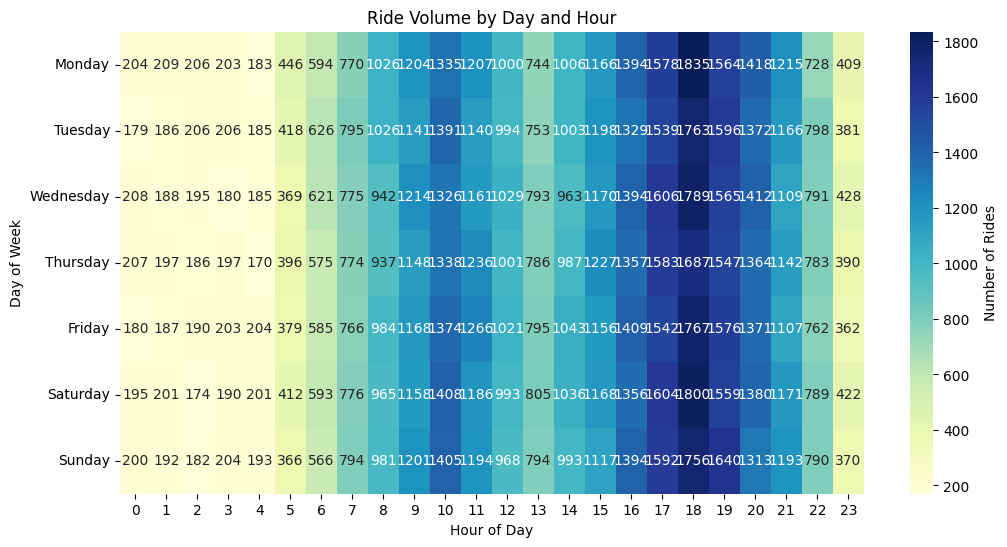

In [10]:
# CELL 9: Heatmap - Ride Volume by Day & Hour
heatmap_data = df.groupby(['Day', 'Hour']).size().unstack(fill_value=0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Number of Rides'})
plt.title("Ride Volume by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

In [11]:
# CELL 10: Insights Summary
print("\n--- 🚀 KEY INSIGHTS ---")
vehicle_success_sr = df.groupby('Vehicle Type')['Is Completed'].mean() * 100
print(f"• Highest Success Rate: {vehicle_success_sr.idxmax()} ({vehicle_success_sr.max():.1f}%)")
print(f"• Most Common Vehicle: {df['Vehicle Type'].mode()[0]}")
print(f"• Top Payment Method: {df['Payment Method'].mode()[0]}")
print(f"• Peak Booking Hour: {df['Hour'].mode()[0]}:00")
print(f"• Avg Customer Rating: {df['Customer Rating'].mean():.2f}")
print(f"• Avg Driver Rating: {df['Driver Ratings'].mean():.2f}")


--- 🚀 KEY INSIGHTS ---
• Highest Success Rate: Uber XL (62.6%)
• Most Common Vehicle: Auto
• Top Payment Method: UPI
• Peak Booking Hour: 18:00
• Avg Customer Rating: 4.40
• Avg Driver Rating: 4.23
